# Notebook 4: Apriori — Agency Procurement Pattern Analysis

## Overview

The Apriori algorithm identifies frequent itemsets: combinations of items
that co-occur across transactions at or above a minimum support threshold
and derives association rules from those itemsets.

In this project, **agencies are transactions** and **NAICS codes are items**.
Each agency's basket contains the unique set of service categories it
contracted in FY2025. Frequent itemsets reveal which combinations of services
are commonly procured together across agencies, exposing latent structure in
government spending patterns.

Association rules are evaluated on two metrics:
- **Support**: proportion of agencies whose basket contains the itemset
- **Confidence**: probability that the consequent is present given the antecedent
- **Lift** : how much more likely the rule holds than by random chance alone.
  Lift > 1 indicates a genuine association beyond base rates.

## Two-Run Analysis

The Department of Defense accounts for 75% of all unique NAICS codes in the
dataset. Its inclusion could inflate support for common services and make
co-occurrence patterns appear more universal than they actually are. To test
this, Apriori is run twice:

- **Section 1:** All agencies including DoD — establishes baseline patterns
- **Section 2:** Excluding DoD and agencies with fewer than 10 contracts to
  test whether patterns hold among civilian agencies independently

If results are consistent across both runs, the association rules reflect
genuine government-wide procurement norms rather than DoD artifacts.

**Input:** `contracts_resolved.csv`  
**Output:** `apriori_frequent_itemsets.csv`, `apriori_association_rules.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

## Setup

NAICS codes are mapped to short human-readable labels for visualization.
All label lookups are defined here and shared across both analysis sections.

In [2]:
# Load data
df = pd.read_csv('contracts_resolved.csv', dtype={'naics_code': str})

# NAICS code to readable label mapping
naics_short = {
    '541611': 'Mgmt Consulting',
    '541519': 'Other Computer Services',
    '518210': 'Cloud/Data Processing',
    '541512': 'Computer Systems Design',
    '541511': 'Custom Programming',
    '561210': 'Facilities Support',
    '541990': 'Other Prof/Tech Services',
    '561990': 'Other Support Services',
    '511210': 'Software Publishers',
    '541690': 'Scientific/Tech Consulting',
    '611430': 'Prof Development Training',
    '541612': 'HR Consulting',
    '541618': 'Other Mgmt Consulting',
    '519290': 'Web/Info Services',
    '561110': 'Office Admin Services',
    '561720': 'Janitorial Services',
}

def label_itemset(itemset):
    return ' + '.join(naics_short.get(c, c) for c in sorted(itemset))

print(f"Shape: {df.shape}")
print(f"Unique agencies: {df['awarding_agency_name'].nunique()}")
print(f"Unique NAICS codes: {df['naics_code'].nunique()}")

Shape: (73350, 7)
Unique agencies: 55
Unique NAICS codes: 787


## Section 1: All Agencies (Including DoD)

Baseline run using all 54 qualifying agencies (one agency had no NAICS codes
meeting the frequency threshold and was dropped from baskets automatically).
The Department of Defense is included here.

NAICS codes are filtered to those appearing in at least 20 of the 54 agencies
before encoding. This reduces the column space from 787 to 36 codes, making
Apriori computationally tractable while retaining only the most broadly
contracted service categories. including too many NAICS codes causes the kernel to crash. A minimum support threshold of 0.5 requires
a NAICS code combination to appear in at least half of all agency baskets.

In [3]:
# Section 1: All agencies, NAICS codes appearing in 20+ agencies
naics_counts_all = df.groupby('naics_code')['awarding_agency_name'].nunique()
common_naics_all = naics_counts_all[naics_counts_all >= 20].index.tolist()

baskets_all = (
    df[df['naics_code'].isin(common_naics_all)]
    .groupby('awarding_agency_name')['naics_code']
    .apply(lambda x: list(x.unique()))
    .reset_index()
)

te1 = TransactionEncoder()
te_array1 = te1.fit_transform(baskets_all['naics_code'])
basket_df1 = pd.DataFrame(te_array1, columns=te1.columns_)

print(f"All-agency basket matrix: {basket_df1.shape}")
print(f"NAICS codes in 20+ agencies: {len(common_naics_all)}")

fi1 = apriori(basket_df1, min_support=0.5, use_colnames=True)
fi1['length'] = fi1['itemsets'].apply(len)

print(f"\nFrequent itemsets (all agencies): {len(fi1)}")
print(fi1['length'].value_counts().sort_index())

All-agency basket matrix: (54, 36)
NAICS codes in 20+ agencies: 36

Frequent itemsets (all agencies): 108
length
1    16
2    40
3    39
4    12
5     1
Name: count, dtype: int64


### Association Rules

Rules are filtered to lift ≥ 1.2 and confidence ≥ 0.5, retaining only
rules that represent genuine non-random associations with reasonable
predictive strength.

In [4]:
rules1 = association_rules(fi1, metric='lift', min_threshold=1.2)
rules1 = rules1[rules1['confidence'] >= 0.5].sort_values('lift', ascending=False)

print(f"Strong rules (all agencies): {len(rules1)}")
print(f"\nTop 10 rules by lift:")
top10_1 = rules1.head(10).copy()
top10_1['ant'] = top10_1['antecedents'].apply(label_itemset)
top10_1['con'] = top10_1['consequents'].apply(label_itemset)
print(top10_1[['ant', 'con', 'support', 'confidence', 'lift']].to_string())

Strong rules (all agencies): 456

Top 10 rules by lift:
                                                                     ant                                                                  con   support  confidence      lift
424                                            Prof Development Training  Computer Systems Design + Other Computer Services + Mgmt Consulting  0.518519    1.000000  1.687500
413  Computer Systems Design + Other Computer Services + Mgmt Consulting                                            Prof Development Training  0.518519    0.875000  1.687500
205                                            Prof Development Training                    Computer Systems Design + Other Computer Services  0.518519    1.000000  1.687500
420                    Computer Systems Design + Other Computer Services                          Mgmt Consulting + Prof Development Training  0.518519    0.875000  1.687500
200                    Computer Systems Design + Other Computer Services  

### Visualization

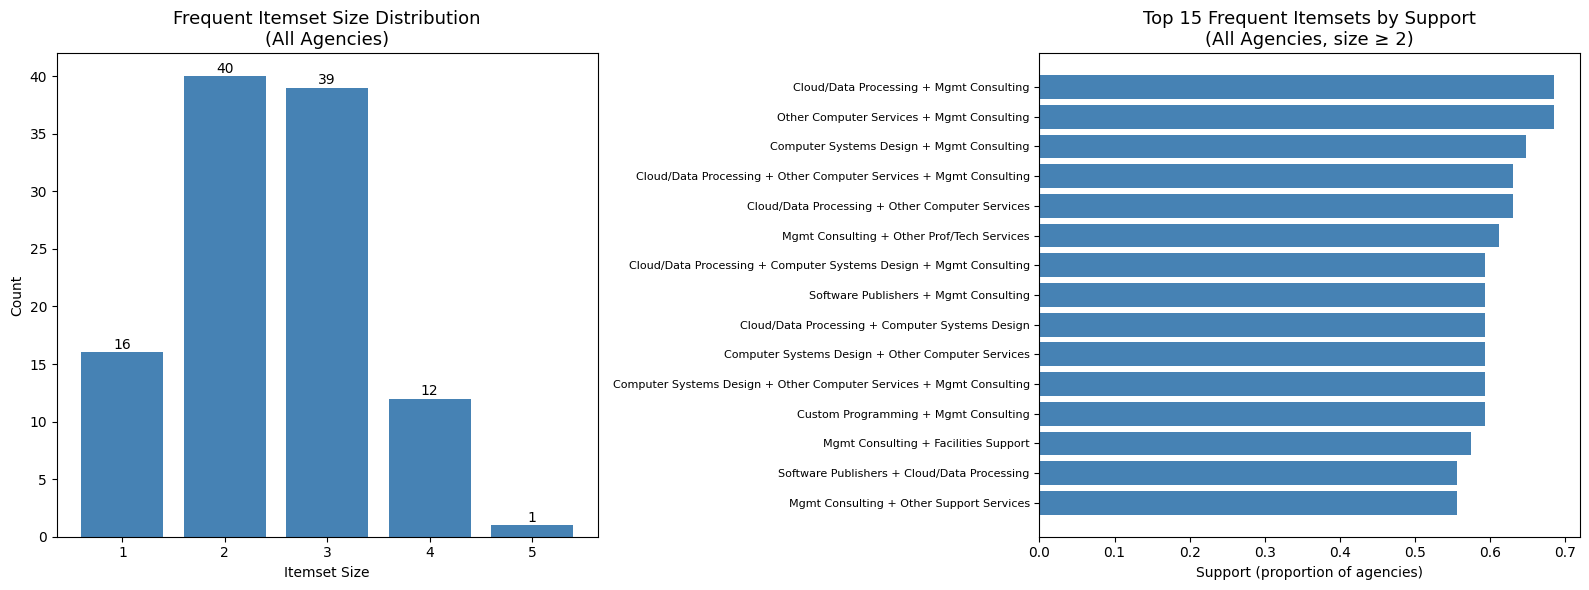

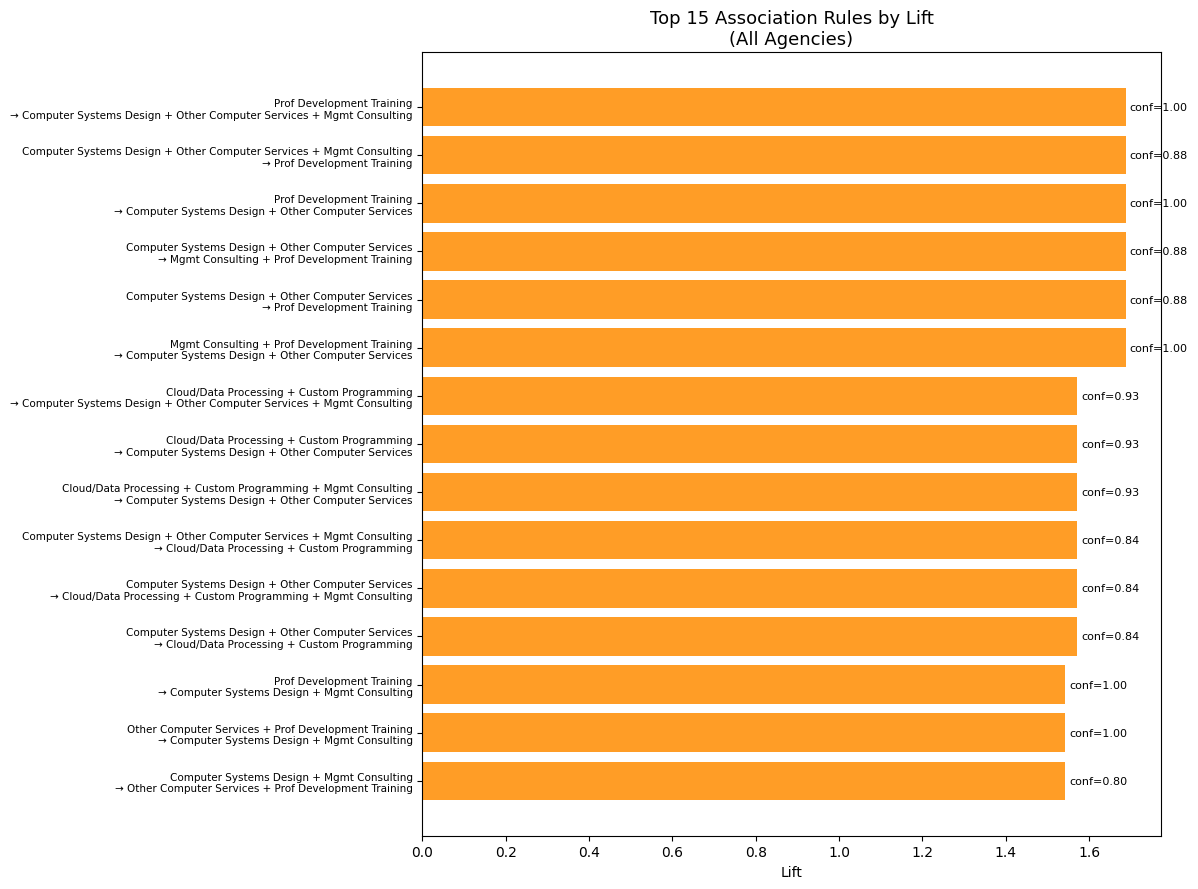

Saved apriori_all_agencies_itemsets.png and apriori_all_agencies_rules.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

size_counts1 = fi1['length'].value_counts().sort_index()
axes[0].bar(size_counts1.index, size_counts1.values, color='steelblue')
axes[0].set_title('Frequent Itemset Size Distribution\n(All Agencies)', fontsize=13)
axes[0].set_xlabel('Itemset Size')
axes[0].set_ylabel('Count')
for i, v in enumerate(size_counts1.values):
    axes[0].text(size_counts1.index[i], v + 0.3, str(v), ha='center', fontsize=10)

top_fi1 = fi1[fi1['length'] >= 2].sort_values('support', ascending=False).head(15).copy()
top_fi1['label'] = top_fi1['itemsets'].apply(label_itemset)
axes[1].barh(top_fi1['label'][::-1], top_fi1['support'][::-1], color='steelblue')
axes[1].set_title('Top 15 Frequent Itemsets by Support\n(All Agencies, size ≥ 2)', fontsize=13)
axes[1].set_xlabel('Support (proportion of agencies)')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('apriori_all_agencies_itemsets.png', dpi=150, bbox_inches='tight')
plt.show()

top_r1 = rules1.head(15).copy()
top_r1['ant_label'] = top_r1['antecedents'].apply(label_itemset)
top_r1['con_label'] = top_r1['consequents'].apply(label_itemset)
top_r1['rule_label'] = top_r1['ant_label'] + '\n→ ' + top_r1['con_label']

fig2, ax = plt.subplots(figsize=(12, 9))
ax.barh(top_r1['rule_label'][::-1], top_r1['lift'][::-1], color='darkorange', alpha=0.85)
for i, (_, row) in enumerate(top_r1[::-1].iterrows()):
    ax.text(row['lift'] + 0.01, i, f"conf={row['confidence']:.2f}", va='center', fontsize=8)
ax.set_title('Top 15 Association Rules by Lift\n(All Agencies)', fontsize=13)
ax.set_xlabel('Lift')
ax.tick_params(axis='y', labelsize=7.5)
plt.tight_layout()
plt.savefig('apriori_all_agencies_rules.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved apriori_all_agencies_itemsets.png and apriori_all_agencies_rules.png")

## Section 2: Excluding DoD and Sparse Agencies

DoD contracts 591 of 787 unique NAICS codes (75%) in the dataset. Agencies
with fewer than 10 total contracts are also excluded as their baskets are too
sparse to contribute meaningful co-occurrence signal.

This leaves 45 qualifying agencies. NAICS codes are filtered to those
appearing in at least 8 of the 45 agencies, and the same support and lift
thresholds are applied as Section 1.

In [6]:
# Section 2: Exclude DoD and sparse agencies (<10 contracts)
agency_counts = df.groupby('awarding_agency_name').size()
qualifying = agency_counts[agency_counts >= 10].index.tolist()
qualifying = [a for a in qualifying if a != 'Department of Defense']

df_filtered = df[df['awarding_agency_name'].isin(qualifying)]

naics_counts_filtered = df_filtered.groupby('naics_code')['awarding_agency_name'].nunique()
common_naics_filtered = naics_counts_filtered[naics_counts_filtered >= 8].index.tolist()

baskets_filtered = (
    df_filtered[df_filtered['naics_code'].isin(common_naics_filtered)]
    .groupby('awarding_agency_name')['naics_code']
    .apply(lambda x: list(x.unique()))
    .reset_index()
)

te2 = TransactionEncoder()
te_array2 = te2.fit_transform(baskets_filtered['naics_code'])
basket_df2 = pd.DataFrame(te_array2, columns=te2.columns_)

print(f"Excluding-DoD basket matrix: {basket_df2.shape}")
print(f"Agencies: {len(qualifying)} (excluded DoD + sparse agencies)")

fi2 = apriori(basket_df2, min_support=0.5, use_colnames=True)
fi2['length'] = fi2['itemsets'].apply(len)

print(f"\nFrequent itemsets (excl. DoD): {len(fi2)}")
print(fi2['length'].value_counts().sort_index())

Excluding-DoD basket matrix: (45, 146)
Agencies: 45 (excluded DoD + sparse agencies)

Frequent itemsets (excl. DoD): 471
length
1     18
2     86
3    163
4    138
5     57
6      9
Name: count, dtype: int64


In [7]:
# Filter to NAICS codes appearing in at least 8 of the 45 agencies (~18%)
naics_agency_counts = df_filtered.groupby('naics_code')['awarding_agency_name'].nunique()
common_naics = naics_agency_counts[naics_agency_counts >= 8].index.tolist()

print(f"NAICS codes appearing in 8+ agencies: {len(common_naics)}")

baskets_filtered = (
    df_filtered[df_filtered['naics_code'].isin(common_naics)]
    .groupby('awarding_agency_name')['naics_code']
    .apply(lambda x: list(x.unique()))
    .reset_index()
)

print(f"Agencies remaining: {len(baskets_filtered)}")

te = TransactionEncoder()
te_array = te.fit_transform(baskets_filtered['naics_code'])
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Basket matrix shape: {basket_df.shape}")

frequent_itemsets = apriori(basket_df, min_support=0.4, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"\nFrequent itemsets found: {len(frequent_itemsets)}")
print(f"\nItemset size distribution:")
print(frequent_itemsets['length'].value_counts().sort_index())

NAICS codes appearing in 8+ agencies: 146
Agencies remaining: 45
Basket matrix shape: (45, 146)

Frequent itemsets found: 12548

Itemset size distribution:
length
1       38
2      307
3     1084
4     2268
5     3076
6     2847
7     1844
8      818
9      229
10      35
11       2
Name: count, dtype: int64


### Association Rules

In [8]:
rules2 = association_rules(fi2, metric='lift', min_threshold=1.2)
rules2 = rules2[rules2['confidence'] >= 0.5].sort_values('lift', ascending=False)

print(f"Strong rules (excl. DoD): {len(rules2)}")
print(f"\nTop 10 rules by lift:")
top10_2 = rules2.head(10).copy()
top10_2['ant'] = top10_2['antecedents'].apply(label_itemset)
top10_2['con'] = top10_2['consequents'].apply(label_itemset)
print(top10_2[['ant', 'con', 'support', 'confidence', 'lift']].to_string())

Strong rules (excl. DoD): 3776

Top 10 rules by lift:
                                                                                                 ant                                                                                             con   support  confidence   lift
3613  Computer Systems Design + Other Computer Services + Mgmt Consulting + Other Prof/Tech Services                                                  Custom Programming + Prof Development Training  0.511111    0.920000  1.725
3765                                              Other Support Services + Prof Development Training  Computer Systems Design + Other Computer Services + Mgmt Consulting + Other Prof/Tech Services  0.511111    0.958333  1.725
2324                                               Cloud/Data Processing + Prof Development Training                  Computer Systems Design + Other Computer Services + Scientific/Tech Consulting  0.511111    0.920000  1.725
3673    Computer Systems Design + Other Co

### Visualization

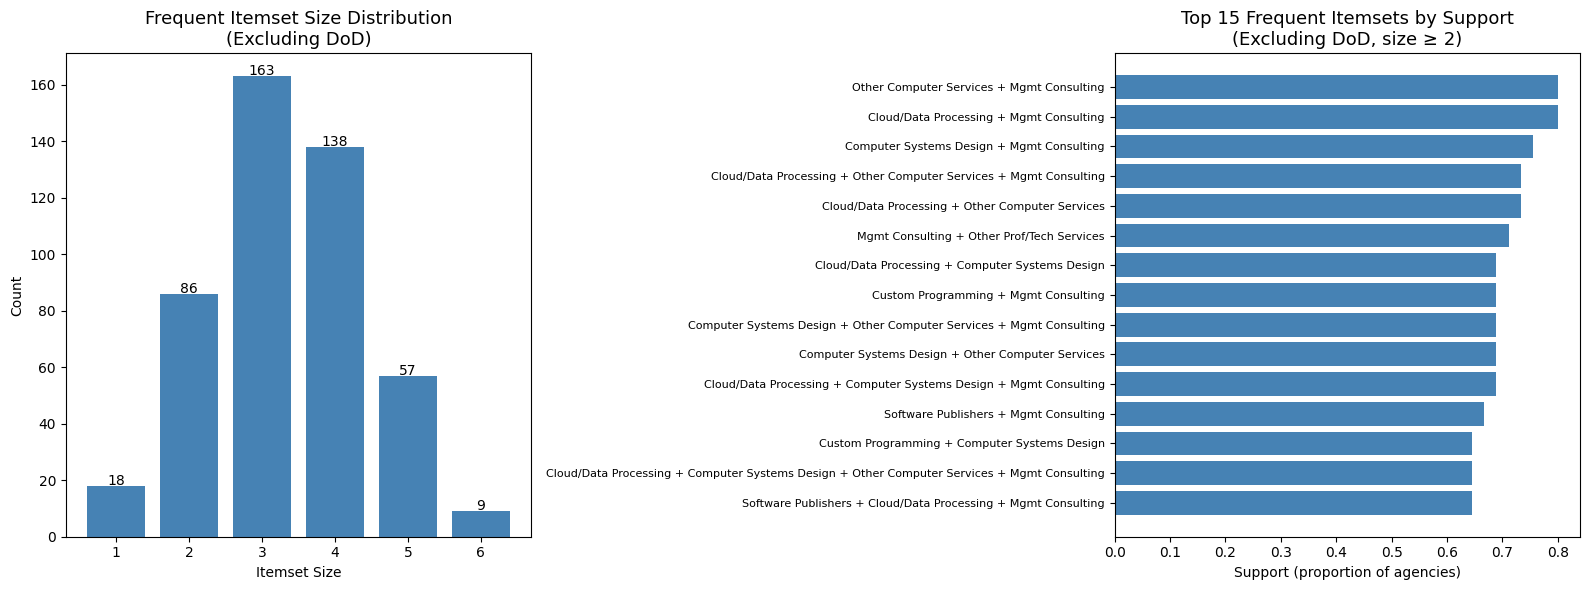

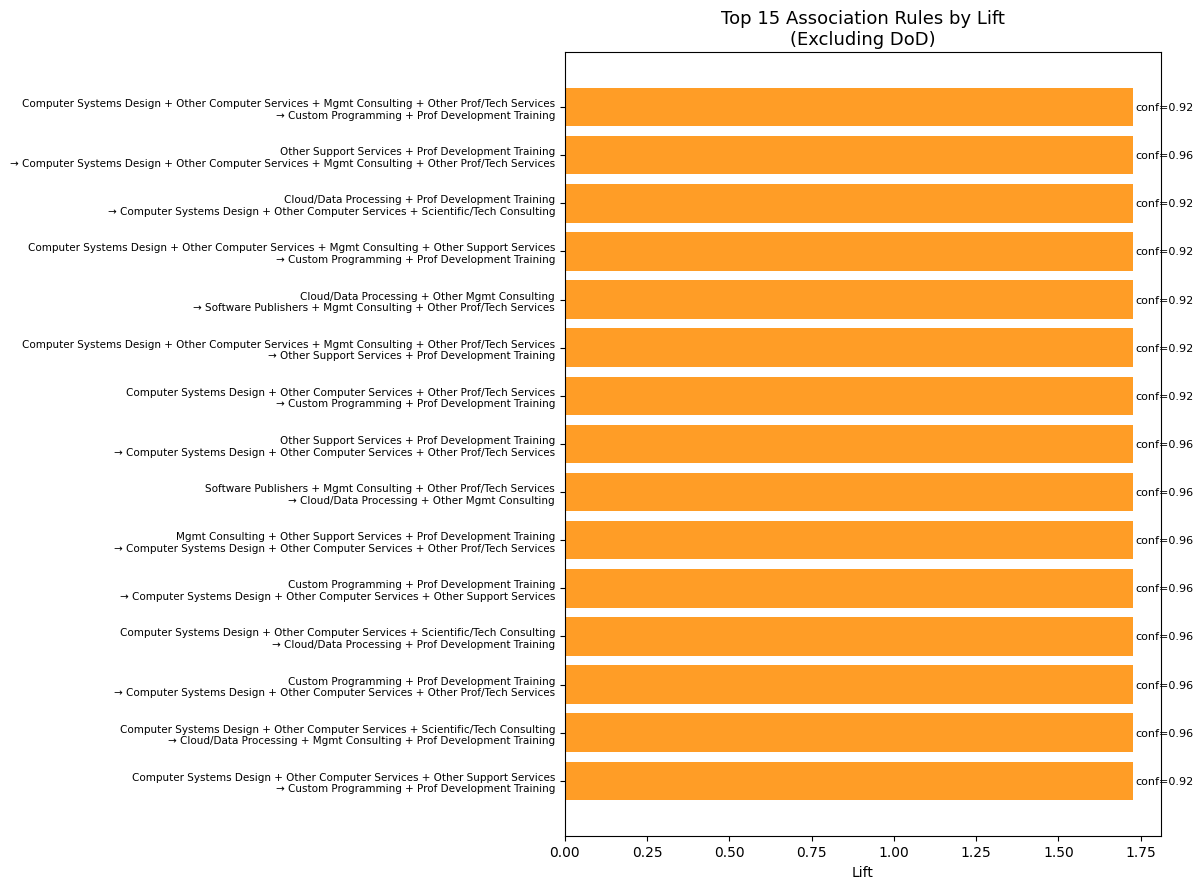

Saved apriori_nodod_itemsets.png and apriori_nodod_rules.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

size_counts2 = fi2['length'].value_counts().sort_index()
axes[0].bar(size_counts2.index, size_counts2.values, color='steelblue')
axes[0].set_title('Frequent Itemset Size Distribution\n(Excluding DoD)', fontsize=13)
axes[0].set_xlabel('Itemset Size')
axes[0].set_ylabel('Count')
for i, v in enumerate(size_counts2.values):
    axes[0].text(size_counts2.index[i], v + 0.3, str(v), ha='center', fontsize=10)

top_fi2 = fi2[fi2['length'] >= 2].sort_values('support', ascending=False).head(15).copy()
top_fi2['label'] = top_fi2['itemsets'].apply(label_itemset)
axes[1].barh(top_fi2['label'][::-1], top_fi2['support'][::-1], color='steelblue')
axes[1].set_title('Top 15 Frequent Itemsets by Support\n(Excluding DoD, size ≥ 2)', fontsize=13)
axes[1].set_xlabel('Support (proportion of agencies)')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('apriori_nodod_itemsets.png', dpi=150, bbox_inches='tight')
plt.show()

top_r2 = rules2.head(15).copy()
top_r2['ant_label'] = top_r2['antecedents'].apply(label_itemset)
top_r2['con_label'] = top_r2['consequents'].apply(label_itemset)
top_r2['rule_label'] = top_r2['ant_label'] + '\n→ ' + top_r2['con_label']

fig2, ax = plt.subplots(figsize=(12, 9))
ax.barh(top_r2['rule_label'][::-1], top_r2['lift'][::-1], color='darkorange', alpha=0.85)
for i, (_, row) in enumerate(top_r2[::-1].iterrows()):
    ax.text(row['lift'] + 0.01, i, f"conf={row['confidence']:.2f}", va='center', fontsize=8)
ax.set_title('Top 15 Association Rules by Lift\n(Excluding DoD)', fontsize=13)
ax.set_xlabel('Lift')
ax.tick_params(axis='y', labelsize=7.5)
plt.tight_layout()
plt.savefig('apriori_nodod_rules.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved apriori_nodod_itemsets.png and apriori_nodod_rules.png")

### DoD Footprint Analysis

Before interpreting the Section 2 results, the scale of DoD's NAICS coverage
is quantified to justify its exclusion and identify agencies too sparse
for meaningful basket analysis.

In [10]:
# Check how many NAICS codes DoD alone contracts
dod_naics = df[df['awarding_agency_name'] == 'Department of Defense']['naics_code'].nunique()
total_naics = df['naics_code'].nunique()
print(f"DoD unique NAICS codes: {dod_naics} out of {total_naics} total")
print(f"DoD contracts: {len(df[df['awarding_agency_name'] == 'Department of Defense'])}")

# Also check which agencies have very few contracts — potential noise
agency_counts = df.groupby('awarding_agency_name').size().sort_values()
print(f"\nSmallest agencies by contract count:")
print(agency_counts.head(10))

DoD unique NAICS codes: 591 out of 787 total
DoD contracts: 31695

Smallest agencies by contract count:
awarding_agency_name
Merit Systems Protection Board              1
American Battle Monuments Commission        2
Consumer Product Safety Commission          2
International Trade Commission              2
United States Chemical Safety Board         3
Federal Maritime Commission                 3
Defense Nuclear Facilities Safety Board     3
National Endowment for the Arts             3
National Transportation Safety Board        4
Executive Office of the President          12
dtype: int64


## Section 3: Comparison & Conclusion
Both runs are compared on itemset count, rule count, maximum lift, and
maximum confidence to determine whether the dominant patterns are DoD-driven
or government-wide.

In [11]:
print("=== Comparison: All Agencies vs Excluding DoD ===")
print(f"{'Metric':<35} {'All Agencies':>15} {'Excl. DoD':>15}")
print("-" * 67)
print(f"{'Agencies':<35} {'54':>15} {'45':>15}")
print(f"{'Frequent itemsets':<35} {len(fi1):>15} {len(fi2):>15}")
print(f"{'Strong association rules':<35} {len(rules1):>15} {len(rules2):>15}")
print(f"{'Max lift':<35} {rules1['lift'].max():>15.3f} {rules2['lift'].max():>15.3f}")
print(f"{'Max confidence':<35} {rules1['confidence'].max():>15.3f} {rules2['confidence'].max():>15.3f}")

print("\nConclusion: Excluding DoD reveals stronger and more numerous association")
print("rules among civilian agencies, confirming that IT and consulting service")
print("co-occurrence patterns are government-wide procurement norms, not artifacts")
print("of DoD's outsized contracting volume.")

=== Comparison: All Agencies vs Excluding DoD ===
Metric                                 All Agencies       Excl. DoD
-------------------------------------------------------------------
Agencies                                         54              45
Frequent itemsets                               108             471
Strong association rules                        456            3776
Max lift                                      1.688           1.725
Max confidence                                1.000           1.000

Conclusion: Excluding DoD reveals stronger and more numerous association
rules among civilian agencies, confirming that IT and consulting service
co-occurrence patterns are government-wide procurement norms, not artifacts
of DoD's outsized contracting volume.


## Save

Frequent itemsets and association rules from both runs are saved to CSV with
a `run` column distinguishing `all_agencies` from `excl_dod` results.

In [12]:
fi1_save = fi1.copy()
fi1_save['itemsets'] = fi1_save['itemsets'].apply(lambda x: ', '.join(sorted(x)))
fi1_save['run'] = 'all_agencies'

fi2_save = fi2.copy()
fi2_save['itemsets'] = fi2_save['itemsets'].apply(lambda x: ', '.join(sorted(x)))
fi2_save['run'] = 'excl_dod'

pd.concat([fi1_save, fi2_save]).to_csv('apriori_frequent_itemsets.csv', index=False)

r1_save = rules1.copy()
r1_save['antecedents'] = r1_save['antecedents'].apply(lambda x: ', '.join(sorted(x)))
r1_save['consequents'] = r1_save['consequents'].apply(lambda x: ', '.join(sorted(x)))
r1_save['run'] = 'all_agencies'

r2_save = rules2.copy()
r2_save['antecedents'] = r2_save['antecedents'].apply(lambda x: ', '.join(sorted(x)))
r2_save['consequents'] = r2_save['consequents'].apply(lambda x: ', '.join(sorted(x)))
r2_save['run'] = 'excl_dod'

pd.concat([r1_save, r2_save]).to_csv('apriori_association_rules.csv', index=False)

print(f"Saved apriori_frequent_itemsets.csv ({len(fi1_save) + len(fi2_save)} total itemsets)")
print(f"Saved apriori_association_rules.csv ({len(r1_save) + len(r2_save)} total rules)")

Saved apriori_frequent_itemsets.csv (579 total itemsets)
Saved apriori_association_rules.csv (4232 total rules)
